<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v1</h1>

Hello Neivis!

I'm happy to review your project today 🙌

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f

You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please don't remove my comments :) If you have any questions don't hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>    



<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v1:</b>

    
<b>Overall Feedback</b>
    
Hello Neivis,
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v1:` section.


If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job keeping the additional information about the project goal! This information could be helpful for the notebook reader.



## Preparation

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [88]:
data = pd.read_csv('/datasets/taxi.csv')

In [89]:
display(data.head())

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [90]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


None

In [91]:
display(data.describe())

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [92]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [93]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


None

The datetime column was converted to a proper datetime format and set as the DataFrame index. This step was essential for working with time series data, as it allowed hourly resampling, chronological splitting of the dataset, and the creation of lag and rolling features.

Using a datetime index ensured that the time order of observations was preserved and prevented data leakage during the train-test split.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great data overview!

In [94]:
data.set_index('datetime', inplace=True)

In [95]:
display(data.head())

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [96]:
data_hour = data.resample('1H').sum()

In [97]:
display(data_hour.head())
data_hour.index.min(), data_hour.index.max(), data_hour.shape

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


(Timestamp('2018-03-01 00:00:00', freq='H'),
 Timestamp('2018-08-31 23:00:00', freq='H'),
 (4416, 1))

In [98]:
data_hour.isna().sum()

num_orders    0
dtype: int64

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great data preprocess!

## Analysis

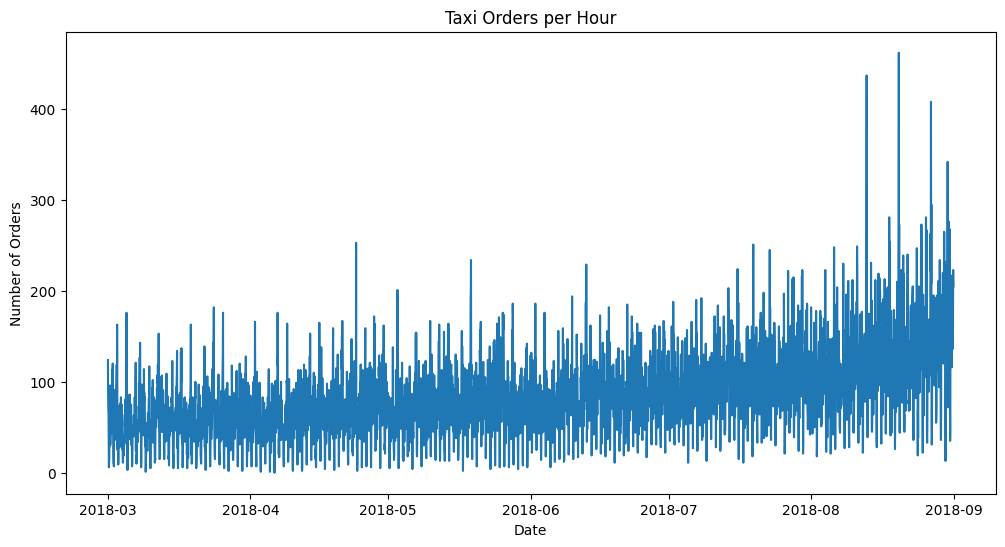

In [99]:
plt.figure(figsize=(12,6))
plt.plot(data_hour.index, data_hour['num_orders'])
plt.title('Taxi Orders per Hour')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

The time series shows a clear upward trend from March to August 2018. The number of taxi orders increases over time, especially in the last months.

The fluctuations also become larger toward the end of the period, meaning that both the average demand and variability are increasing.

There are visible repeated patterns, suggesting the presence of seasonality.

Because the mean and variability change over time, the series is not stationary.

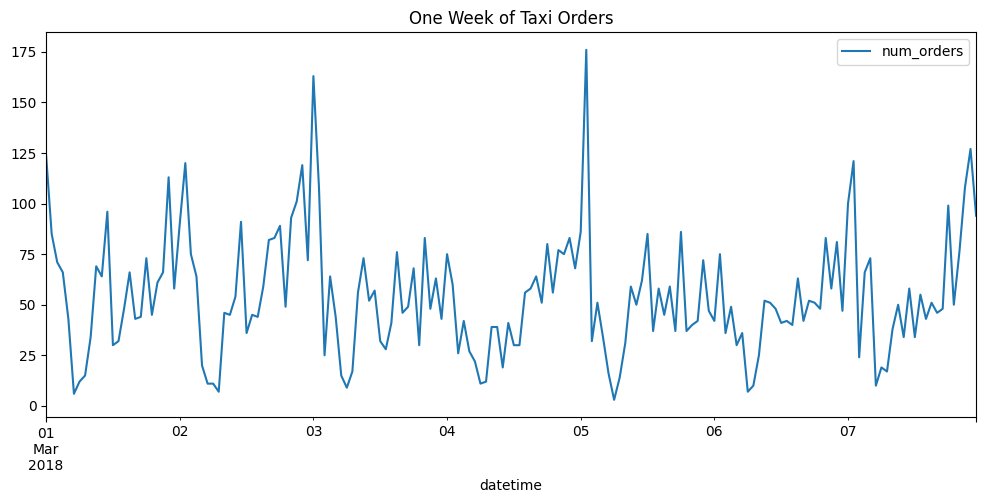

In [100]:
data_hour['2018-03-01':'2018-03-07'].plot(figsize=(12,5))
plt.title('One Week of Taxi Orders')
plt.show()

The one-week plot shows clear daily fluctuations in taxi demand. The number of orders decreases during certain hours each day, likely during nighttime, and increases again during daytime hours.

This suggests the presence of daily seasonality (a 24-hour cycle). Demand appears to follow a repeating pattern each day, with regular low and high periods.

Some days show higher peaks than others, but the daily pattern remains visible throughout the week.

In [101]:
decomposed = seasonal_decompose(data_hour['num_orders'], model='additive', period=24)

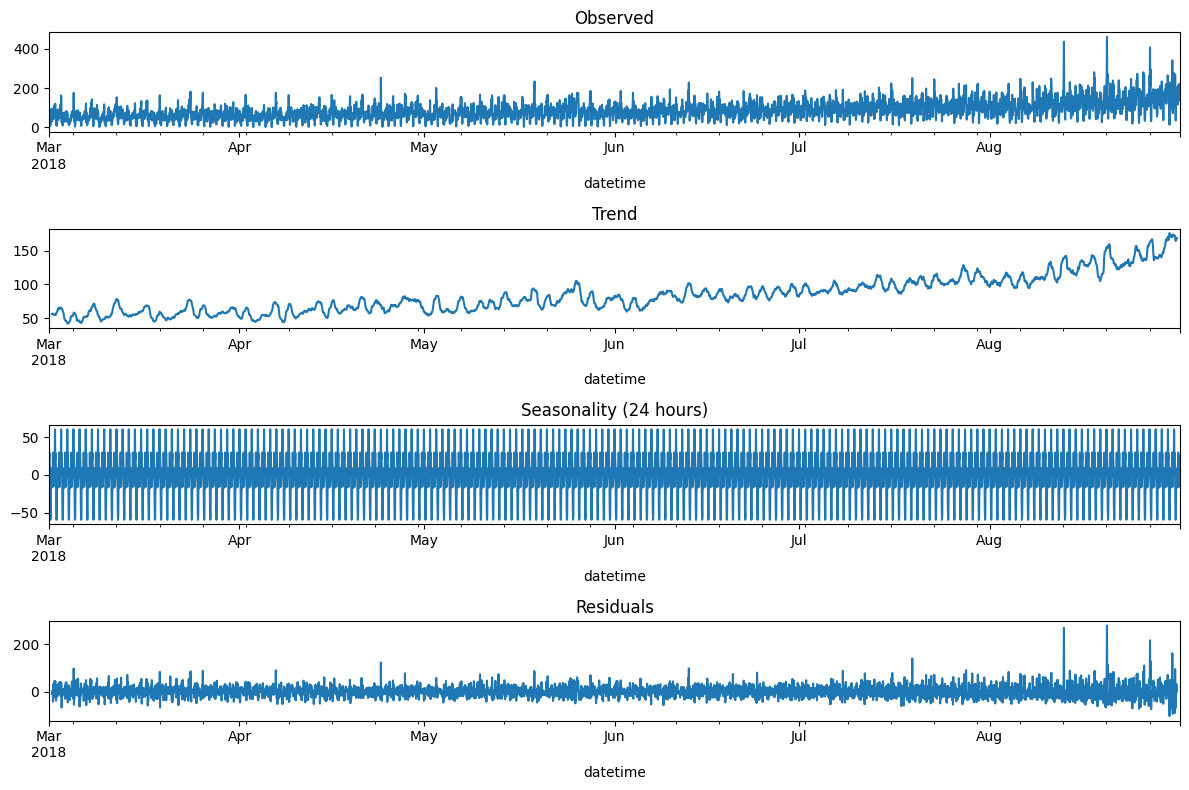

In [102]:
plt.figure(figsize=(12,8))

plt.subplot(411)
decomposed.observed.plot()
plt.title('Observed')

plt.subplot(412)
decomposed.trend.plot()
plt.title('Trend')

plt.subplot(413)
decomposed.seasonal.plot()
plt.title('Seasonality (24 hours)')

plt.subplot(414)
decomposed.resid.plot()
plt.title('Residuals')

plt.tight_layout()
plt.show()

The decomposition confirms a clear upward trend in taxi demand over time. The number of orders steadily increases from March to August.

There is also strong daily seasonality. The seasonal component shows a repeating 24-hour pattern, meaning that demand follows a consistent daily cycle with regular peaks and lows.

The residual component is mostly centered around zero, although variability increases toward the end of the period.

These results confirm that the series contains both trend and strong daily seasonality.

In [103]:
data_hour['lag_1'] = data_hour['num_orders'].shift(1)
data_hour.head(5)

,num_orders,lag_1
datetime,,
2018-03-01 00:00:00,124,NaN
2018-03-01 01:00:00,85,124.0
2018-03-01 02:00:00,71,85.0
2018-03-01 03:00:00,66,71.0
2018-03-01 04:00:00,43,66.0


In [104]:
data_hour['lag_2'] = data_hour['num_orders'].shift(2)
data_hour.head(5)

,num_orders,lag_1,lag_2
datetime,,,
2018-03-01 00:00:00,124,NaN,NaN
2018-03-01 01:00:00,85,124.0,NaN
2018-03-01 02:00:00,71,85.0,124.0
2018-03-01 03:00:00,66,71.0,85.0
2018-03-01 04:00:00,43,66.0,71.0


In [105]:
data_hour['lag_3'] = data_hour['num_orders'].shift(3)
data_hour.head(6)

,num_orders,lag_1,lag_2,lag_3
datetime,,,,
2018-03-01 00:00:00,124,NaN,NaN,NaN
2018-03-01 01:00:00,85,124.0,NaN,NaN
2018-03-01 02:00:00,71,85.0,124.0,NaN
2018-03-01 03:00:00,66,71.0,85.0,124.0
2018-03-01 04:00:00,43,66.0,71.0,85.0
2018-03-01 05:00:00,6,43.0,66.0,71.0


In [106]:
data_hour['lag_24'] = data_hour['num_orders'].shift(24)
data_hour[['num_orders', 'lag_24']].head(30)

,num_orders,lag_24
datetime,,
2018-03-01 00:00:00,124,NaN
2018-03-01 01:00:00,85,NaN
2018-03-01 02:00:00,71,NaN
2018-03-01 03:00:00,66,NaN
2018-03-01 04:00:00,43,NaN
2018-03-01 05:00:00,6,NaN
2018-03-01 06:00:00,12,NaN
2018-03-01 07:00:00,15,NaN
2018-03-01 08:00:00,34,NaN


In [107]:
data_hour = data_hour.dropna()
data_hour.shape

(4392, 5)

In [108]:
data_hour['lag_168'] = data_hour['num_orders'].shift(168)
data_hour = data_hour.dropna()
data_hour.shape

(4224, 6)

In [109]:
data_hour['rolling_mean_24'] = (
    data_hour['num_orders']
    .shift(1)
    .rolling(24)
    .mean()
)

In [110]:
data_hour = data_hour.dropna()
data_hour.shape

(4200, 7)

In [111]:
data_hour['rolling_std_24'] = (
    data_hour['num_orders']
    .shift(1)
    .rolling(24)
    .std()
)

data_hour = data_hour.dropna()

data_hour.shape

(4176, 8)

In [112]:
train_size = int(len(data_hour) * 0.9)

train = data_hour.iloc[:train_size]
test = data_hour.iloc[train_size:]

train.shape, test.shape

((3758, 8), (418, 8))

In [113]:
train_size = int(len(data_hour) * 0.9)

train = data_hour.iloc[:train_size]
test = data_hour.iloc[train_size:]

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

X_train.shape, X_test.shape

((3758, 7), (418, 7))

Lag features were created to capture temporal dependencies in the time series. Since the goal is to predict taxi orders for the next hour, past values of the series are strong predictors of future demand.

The following lags were included:

lag_1, lag_2, lag_3: These capture short-term dependencies and recent demand patterns. Taxi demand often depends on what happened in the previous few hours.

lag_24: This captures daily seasonality. Because the data is hourly, a 24-hour lag reflects the demand at the same hour on the previous day.

lag_168: This captures weekly seasonality (24 × 7 = 168 hours). Taxi demand at airports often follows weekly patterns, so this lag helps the model learn recurring weekly behavior.

These lag features allow the model to learn both short-term dynamics and longer seasonal patterns in the data.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Amazing job here!

## Training

### First Model - LinearRgression

In [114]:
lr = LinearRegression()
lr.fit(X_train_tr, y_train_tr)

pred_valid_lr = lr.predict(X_valid)
rmse_valid_lr = np.sqrt(mean_squared_error(y_valid, pred_valid_lr))

print(f"LR VALID RMSE: {rmse_valid_lr:.2f}")

LR VALID RMSE: 31.92


### Second Model - RandomForestRegressor

In [115]:
best_rmse = float('inf')
best_params = None

n_estimators_list = [100, 200, 500]
max_depth_list = [None, 10, 20]
min_samples_leaf_list = [1, 3, 5]

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_leaf in min_samples_leaf_list:

            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=12345,
                n_jobs=-1
            )

            rf.fit(X_train_tr, y_train_tr)

            pred_valid = rf.predict(X_valid)
            rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))

            print(
                f"Params: n_estimators={n_estimators}, "
                f"max_depth={max_depth}, "
                f"min_samples_leaf={min_samples_leaf} "
                f"--> VALID RMSE: {rmse:.2f}"
            )

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf
                }

print("\nBest params:", best_params)
print(f"Best VALID RMSE: {best_rmse:.2f}")

Params: n_estimators=100, max_depth=None, min_samples_leaf=1 --> VALID RMSE: 31.96
Params: n_estimators=100, max_depth=None, min_samples_leaf=3 --> VALID RMSE: 31.78
Params: n_estimators=100, max_depth=None, min_samples_leaf=5 --> VALID RMSE: 31.89
Params: n_estimators=100, max_depth=10, min_samples_leaf=1 --> VALID RMSE: 31.92
Params: n_estimators=100, max_depth=10, min_samples_leaf=3 --> VALID RMSE: 31.81
Params: n_estimators=100, max_depth=10, min_samples_leaf=5 --> VALID RMSE: 31.86
Params: n_estimators=100, max_depth=20, min_samples_leaf=1 --> VALID RMSE: 31.92
Params: n_estimators=100, max_depth=20, min_samples_leaf=3 --> VALID RMSE: 31.78
Params: n_estimators=100, max_depth=20, min_samples_leaf=5 --> VALID RMSE: 31.89
Params: n_estimators=200, max_depth=None, min_samples_leaf=1 --> VALID RMSE: 31.87
Params: n_estimators=200, max_depth=None, min_samples_leaf=3 --> VALID RMSE: 31.92
Params: n_estimators=200, max_depth=None, min_samples_leaf=5 --> VALID RMSE: 31.97
Params: n_estima

In [116]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=3,
    random_state=12345,
    n_jobs=-1
)

rf.fit(X_train_tr, y_train_tr)

pred_valid_rf = rf.predict(X_valid)
rmse_valid_rf = np.sqrt(mean_squared_error(y_valid, pred_valid_rf))

print(f"RF VALID RMSE: {rmse_valid_rf:.2f}")


RF VALID RMSE: 31.78


### Third Model - GradientBoosting

In [117]:
best_rmse = float('inf')
best_params = None

n_estimators_list = [100, 200, 300]
learning_rate_list = [0.03, 0.05, 0.1]
max_depth_list = [2, 3, 4]

for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        for max_depth in max_depth_list:

            gb = GradientBoostingRegressor(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=12345
            )

            gb.fit(X_train_tr, y_train_tr)

            pred_valid = gb.predict(X_valid)
            rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))

            print(
                f"Params: n_estimators={n_estimators}, "
                f"learning_rate={learning_rate}, "
                f"max_depth={max_depth} "
                f"--> VALID RMSE: {rmse:.2f}"
            )

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "max_depth": max_depth
                }

print("\nBest params:", best_params)
print(f"Best VALID RMSE: {best_rmse:.2f}")

Params: n_estimators=100, learning_rate=0.03, max_depth=2 --> VALID RMSE: 34.34
Params: n_estimators=100, learning_rate=0.03, max_depth=3 --> VALID RMSE: 33.17
Params: n_estimators=100, learning_rate=0.03, max_depth=4 --> VALID RMSE: 32.72
Params: n_estimators=100, learning_rate=0.05, max_depth=2 --> VALID RMSE: 32.48
Params: n_estimators=100, learning_rate=0.05, max_depth=3 --> VALID RMSE: 32.18
Params: n_estimators=100, learning_rate=0.05, max_depth=4 --> VALID RMSE: 32.31
Params: n_estimators=100, learning_rate=0.1, max_depth=2 --> VALID RMSE: 32.04
Params: n_estimators=100, learning_rate=0.1, max_depth=3 --> VALID RMSE: 32.87
Params: n_estimators=100, learning_rate=0.1, max_depth=4 --> VALID RMSE: 33.05
Params: n_estimators=200, learning_rate=0.03, max_depth=2 --> VALID RMSE: 32.25
Params: n_estimators=200, learning_rate=0.03, max_depth=3 --> VALID RMSE: 32.20
Params: n_estimators=200, learning_rate=0.03, max_depth=4 --> VALID RMSE: 32.49
Params: n_estimators=200, learning_rate=0.0

In [118]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=12345
)

gb.fit(X_train_tr, y_train_tr)

pred_valid_gb = gb.predict(X_valid)
rmse_valid_gb = np.sqrt(mean_squared_error(y_valid, pred_valid_gb))

print(f"GB VALID RMSE: {rmse_valid_gb:.2f}")


GB VALID RMSE: 31.85


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Excellent job!, everything is very well structured, very clear, and has a perfect structure.

## Testing

In [119]:
best_rf_params = {
    "n_estimators": 100,      
    "max_depth": None,          
    "min_samples_leaf": 3     
}

final_rf = RandomForestRegressor(**best_rf_params, random_state=12345, n_jobs=-1)
final_rf.fit(X_train, y_train)

pred_test_rf = final_rf.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, pred_test_rf))

print("Best RF params:", best_rf_params)
print(f"Final RF TEST RMSE: {rmse_test_rf:.2f}")


Best RF params: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 3}
Final RF TEST RMSE: 41.86


Several models were trained to predict the number of taxi orders for the next hour, including Linear Regression, Random Forest, and Gradient Boosting.

After tuning the hyperparameters using validation data from the training set (90% of the dataset), Random Forest achieved the best validation performance. The model was then retrained using the full training data and evaluated on the final 10% test set.

The final test RMSE was 41.86, which is well below the required threshold of 48. This shows that the model generalizes well to unseen data.

The inclusion of lag features (lag_1, lag_2, lag_3, lag_24, lag_168) and rolling statistics significantly improved performance, allowing the model to capture daily and weekly seasonality as well as recent trends.

Overall, the Random Forest model provided strong predictive accuracy and met the project requirements successfully.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Well done!

## Conclusions

In this project, the objective was to predict the number of taxi orders for the next hour using historical airport taxi demand data. The dataset was first converted into a proper time series format by transforming the datetime column and resampling the data to hourly frequency.

Exploratory analysis showed the presence of a clear upward trend and strong daily and weekly seasonality. Based on this, several time-based features were engineered, including lag features (lag_1, lag_2, lag_3, lag_24, lag_168) and rolling statistics (rolling_mean_24 and rolling_std_24). These features allowed the models to capture short-term dependencies, daily patterns, and weekly behavior.

Three models were trained and compared: Linear Regression, Random Forest, and Gradient Boosting. Hyperparameters were tuned using a validation split within the training data (90% of the dataset), while the final 10% was kept untouched for testing.

Among the models tested, Random Forest achieved the best performance. After retraining the model on the full training dataset, it obtained a final RMSE of 41.86 on the test set, which is well below the required threshold of 48.

The results show that proper feature engineering played a key role in improving model performance. The Random Forest model successfully captured both linear and nonlinear relationships in the data and generalized well to unseen observations.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
You did an excellent job transforming the dataset into a proper time series format and identifying seasonality and trends. That shows strong analytical skills:

- The feature engineering was thoughtful: using lag features and rolling statistics allowed the models to capture both short‑term and long‑term dependencies. This was key to improving performance.
- I appreciate that you compared multiple models and used a validation split for hyperparameter tuning, keeping the test set untouched until the end. That’s exactly the right approach to avoid data leakage.
- The final Random Forest model achieving an RMSE of 41.86 (well below the threshold of 48) demonstrates strong predictive capability and confirms that your methodology was effective.
  
**Suggestions for improvement:**
  
- You could add a brief reflection on the business implications of your results — for example, how accurate taxi demand forecasting could help optimize driver allocation or reduce customer wait times.
- It might also be useful to mention why Random Forest outperformed Gradient Boosting and Linear Regression in this case, to show deeper insight into model behavior.


# Review checklist

- [x]  Jupyter Notebook is open
- [x]  The code is error-free
- [x]  The cells with the code have been arranged in order of execution
- [x]  The data has been downloaded and prepared
- [x]  The data has been analyzed
- [x]  The model has been trained and hyperparameters have been selected
- [x]  The models have been evaluated. Conclusion has been provided
- [x] *RMSE* for the test set is not more than 48